In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import pickle


def interactive_plot(data):
    planning_steps = np.array(sorted(data))
    if planning_steps.size == 0:
        raise ValueError("data must contain at least one planning step")

    algorithm_names = list(data[int(planning_steps[0])].keys())
    first_step = data[int(planning_steps[0])]
    first_series = [np.asarray(first_step[name], dtype=float) for name in algorithm_names]
    max_len = max(series.size for series in first_series)
    x = np.arange(max_len)

    fig, ax = plt.subplots(figsize=(10, 6))
    plt.subplots_adjust(bottom=0.22)

    lines = {}
    y_min = min(float(series.min()) for series in first_series)
    y_max = max(float(series.max()) for series in first_series)
    if y_min == y_max:
        y_min -= 1.0
        y_max += 1.0

    for name, series in zip(algorithm_names, first_series):
        line, = ax.plot(np.arange(series.size), series, label=name, linewidth=2)
        lines[name] = line

    ax.set_xlabel("Time Steps")
    ax.set_ylabel("Cumulative Reward")
    ax.set_title(f"Planning Steps: {int(planning_steps[0])}")
    ax.set_xlim(0, max_len - 1 if max_len > 1 else 1)
    ax.set_ylim(y_min, y_max)
    ax.legend()

    slider_ax = fig.add_axes((0.12, 0.08, 0.76, 0.04))
    slider = Slider(
        ax=slider_ax,
        label="Planning Steps",
        valmin=0,
        valmax=len(planning_steps) - 1,
        valinit=0,
        valstep=1,
    )

    def update(_):
        step = int(planning_steps[int(slider.val)])
        run = data[step]
        local_min = np.inf
        local_max = -np.inf

        for name in algorithm_names:
            series = np.asarray(run[name], dtype=float)
            lines[name].set_data(np.arange(series.size), series)
            local_min = min(local_min, float(series.min()))
            local_max = max(local_max, float(series.max()))

        if local_min == local_max:
            local_min -= 1.0
            local_max += 1.0

        ax.set_ylim(local_min, local_max)
        ax.set_title(f"Planning Steps: {step}")
        fig.canvas.draw_idle()

    slider.on_changed(update)
    plt.show()


/var/folders/w8/0tgrs0v56_3ggc8s0zz0fbd00000gq/T/ipykernel_11662/1033108.py:40: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider = Slider(


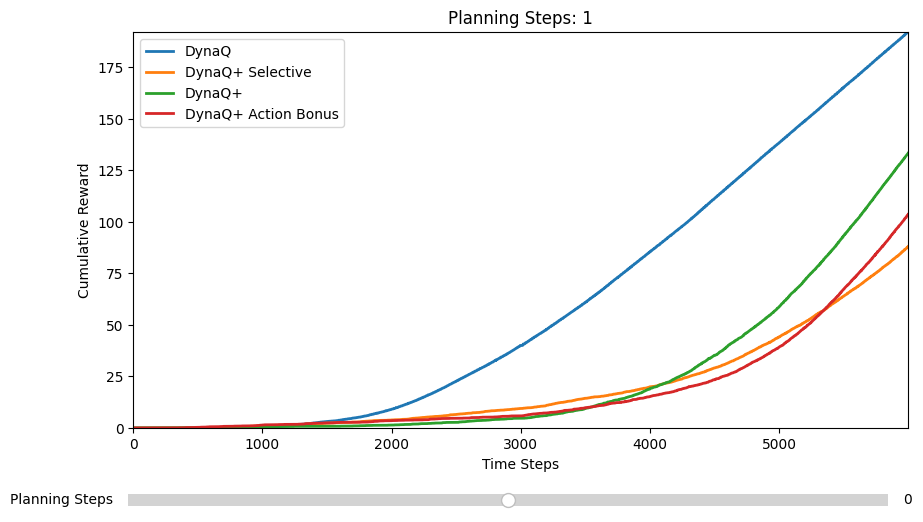

In [9]:
with open("data.pickle", "rb") as f:
    data = pickle.load(f)
interactive_plot(data)

/var/folders/w8/0tgrs0v56_3ggc8s0zz0fbd00000gq/T/ipykernel_11662/1033108.py:40: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  slider = Slider(


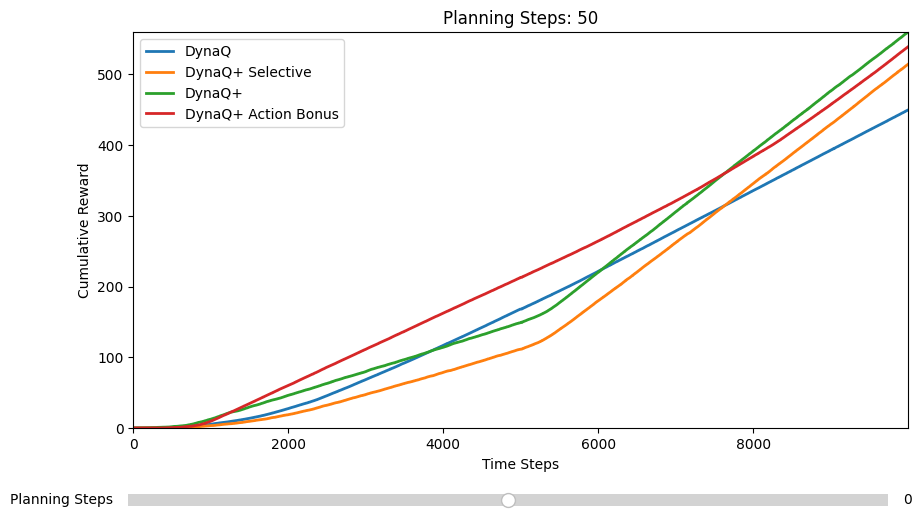

In [10]:
with open("data.pickle", "rb") as f:
    data = pickle.load(f)
interactive_plot(data)

In [14]:
with open("data.pickle", "rb") as f:
    data = pickle.load(f)
    
data.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50])

In [15]:
with open('data1.pickle', 'rb') as f:
    data1:dict = pickle.load(f)

for key, value in data1.items():
    data[key] = data1[key]


with open("6k step switch.pickle", 'wb') as f:
    pickle.dump(data, f)

In [20]:
import plotly

with open("6k step switch.pickle", "rb") as f:
    data = pickle.load(f)



In [40]:
import plotly.graph_objects as go
import numpy as np

def export_dual_theme_plotly(data, base_filename="planning_plot"):
    planning_steps = sorted(data.keys())
    algorithm_names = list(data[planning_steps[0]].keys())
    
    # Pre-calculate global Y-limits to prevent axis "jumping"
    all_values = [val for step in data.values() for series in step.values() for val in series]
    y_min, y_max = min(all_values), max(all_values)
    # Add 5% padding
    padding = (y_max - y_min) * 0.05
    y_range = [y_min - padding, y_max + padding]

    for theme in ['plotly_white', 'plotly_dark']:
        frames = []
        for step in planning_steps:
            frame_data = [
                go.Scatter(x=np.arange(len(data[step][name])), 
                           y=data[step][name], 
                           name=name,
                           mode='lines',
                           line=dict(width=2)) 
                for name in algorithm_names
            ]
            frames.append(go.Frame(data=frame_data, name=str(step)))

        fig = go.Figure(data=frames[0].data, frames=frames)

        # Slider config: immediate redraw, no animation
        sliders = [{
            "active": 0,
            "currentvalue": {"prefix": "Planning Steps: "},
            "pad": {"t": 50},
            "steps": [
                {
                    "args": [[f.name], {
                        "frame": {"duration": 0, "redraw": True}, 
                        "mode": "immediate",
                        "fromcurrent": True,
                        "transition": {"duration": 0}
                    }],
                    "label": f.name,
                    "method": "animate"
                } for f in frames
            ],
        }]

        fig.update_layout(
            template=theme,
            sliders=sliders,
            xaxis_title="Time Steps",
            yaxis_title="Cumulative Reward",
            yaxis=dict(range=y_range), # Fixed range for stability
            # margin=dict(l=20, r=20, t=40, b=20),
            # --- TRANSPARENCY SETTINGS ---
            paper_bgcolor='rgba(0,0,0,0)',
            plot_bgcolor='rgba(0,0,0,0)',
        )

        suffix = "light" if theme == "plotly_white" else "dark"
        # div_id is used by the JavaScript arrow-key listener
        fig.write_html(f"{base_filename}_{suffix}.html", 
                       full_html=False, 
                       include_plotlyjs='cdn',
                       div_id=f"plotly-{suffix}")

# export_dual_theme_plotly(data)

export_dual_theme_plotly(data)

In [38]:
export_dual_theme_plotly(data)